In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import scanpy as sc
import numba as nb
import SOAPy_st as sp

In [2]:
import torch

# NSCLC

In [3]:
df=pd.read_csv("./data/NSCLC/NSCLC.csv")
df=df[df["section"]=="Lung6"].copy()

In [4]:
genes=torch.load("./data/NSCLC/genes.pth")
data=df[genes]
metadata=df[['CenterX_global_px','CenterY_global_px']]

In [5]:
adata = sp.pp.read_csv2adata(
    express = data,
    meta = metadata,
    spatial = ['CenterX_global_px', 'CenterY_global_px']
)

In [6]:
adata.obs['cluster'] = df['CellType'].values.tolist()

In [7]:
sc.pp.normalize_per_cell(adata,counts_per_cell_after=10000)
sc.pp.log1p(adata)

In [8]:
adata

AnnData object with n_obs × n_vars = 89948 × 960
    obs: 'CenterX_global_px', 'CenterY_global_px', 'cluster', 'n_counts'
    uns: 'log1p'
    obsm: 'spatial'

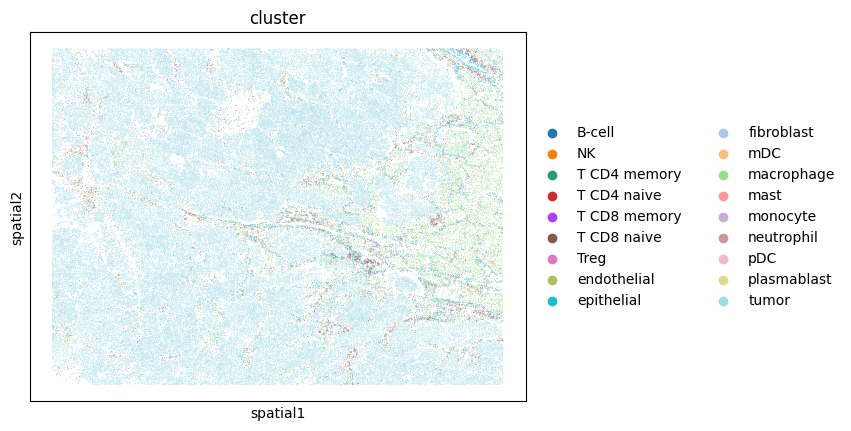

In [9]:
sc.pl.embedding(adata, basis="spatial", color='cluster')

In [10]:
lr_pairs = sp.tl.lr_pairs(
    'human',
    Annotation_key='annotation',
    ligand_key='ligand_symbol',
    receptor_key='receptor_symbol'
)
lr_pairs.get_complexes()

In [11]:
from scipy import sparse
adata = sp.tl.cell_type_level_communication(
    adata=adata,
    lr_pairs=lr_pairs,
    cluster_key='cluster',
    n_iters=100,
    m=0.5,
    contact_key='Cell-Cell Contact',
    secretory_key='Secreted Signaling',
    secretory_radius=100
)

In contact mode, The average number of neighbors is 5.699400758224288
In contact mode, total of 0 spots have no neighbors


143 contact ligand-receptor pairs.:   0%|           [ time left: ? ]

143 contact ligand-receptor pairs.:   1%|           [ time left: 09:18 ]

143 contact ligand-receptor pairs.:   1%|▏          [ time left: 04:46 ]

143 contact ligand-receptor pairs.:   2%|▏          [ time left: 03:19 ]

...

217 secretory ligand-receptor pairs.:  99%|█████████▊ [ time left: 00:02 ]

217 secretory ligand-receptor pairs.:  99%|█████████▉ [ time left: 00:01 ]

217 secretory ligand-receptor pairs.: 100%|█████████▉ [ time left: 00:00 ]

217 secretory ligand-receptor pairs.: 100%|██████████ [ time left: 00:00 ]

217 secretory ligand-receptor pairs.: 100%|██████████ [ time left: 00:00 ]

In [12]:
print(adata)

AnnData object with n_obs × n_vars = 89948 × 960
    obs: 'CenterX_global_px', 'CenterY_global_px', 'cluster', 'n_counts'
    uns: 'log1p', 'cluster_colors', 'SOAPy'
    obsm: 'spatial'


In [13]:
adata.uns['SOAPy']

{'celltype_comm_score': {'celltype': ['B-cell',
   'NK',
   'T CD4 memory',
   'T CD4 naive',
   'T CD8 memory',
   'T CD8 naive',
   'Treg',
   'endothelial',
   'epithelial',
   'fibroblast',
   'mDC',
   'macrophage',
   'mast',
   'monocyte',
   'neutrophil',
   'pDC',
   'plasmablast',
   'tumor'],
  'contact': {'names': ['COL1A1:ITGA1&ITGB1',
    'COL1A2:ITGA1&ITGB1',
    'COL4A1:ITGA1&ITGB1',
    'COL4A2:ITGA1&ITGB1',
    'COL4A5:ITGA1&ITGB1',
    'COL6A1:ITGA1&ITGB1',
    'COL6A2:ITGA1&ITGB1',
    'COL6A3:ITGA1&ITGB1',
    'COL9A1:ITGA1&ITGB1',
    'COL9A2:ITGA1&ITGB1',
    'COL9A3:ITGA1&ITGB1',
    'COL1A1:ITGA2&ITGB1',
    'COL1A2:ITGA2&ITGB1',
    'COL4A1:ITGA2&ITGB1',
    'COL4A2:ITGA2&ITGB1',
    'COL4A5:ITGA2&ITGB1',
    'COL6A1:ITGA2&ITGB1',
    'COL6A2:ITGA2&ITGB1',
    'COL6A3:ITGA2&ITGB1',
    'COL9A1:ITGA2&ITGB1',
    'COL9A2:ITGA2&ITGB1',
    'COL9A3:ITGA2&ITGB1',
    'FN1:ITGA3&ITGB1',
    'FN1:ITGA5&ITGB1',
    'THBS1:ITGA3&ITGB1',
    'THBS2:ITGA3&ITGB1',
    'CO

In [14]:
import networkx as nx

import logging as logg

def _get_info_from_sample(
        adata,
        sample_id = None,
        key = None,
        printf = True
):
    """
    Getting information
    """

    if 'SOAPy' not in adata.uns.keys():
        if printf:
            logg.error('SOAPy was not found in adata.uns', exc_info=True)
        raise KeyError()

    if sample_id is None:
        if key not in adata.uns['SOAPy'].keys():
            if printf:
                logg.error(f'{key} analysis of {sample_id} was not present, please conduct {key} analysis first',
                           exc_info=True)
            raise KeyError()
        data = adata.uns['SOAPy'][key]
    else:
        if key not in adata.uns['SOAPy'][sample_id].keys():
            if printf:
                logg.error(f'{key} analysis of {sample_id} was not present, please conduct {key} analysis first',
                           exc_info=True)
            raise KeyError()
        data = adata.uns['SOAPy'][sample_id][key]

    return data


def _get_lr_data(adata, sample_id, lr_type):

    data = _get_info_from_sample(adata=adata, sample_id=sample_id, key='celltype_comm_score')
    score = data[lr_type]['sig_celltype']
    title = f'cell-cell {lr_type} communication'

    return score, title

def graph_to_strength_df(G: nx.MultiDiGraph, nodes=None) -> pd.DataFrame:
    """
    Convert a (multi)directed graph with edge attribute 'weight' into a
    sender x receiver dataframe of interaction strengths. Parallel edges are summed.
    """
    if nodes is None:
        nodes = list(G.nodes())
    A = nx.to_numpy_array(
        G,
        nodelist=nodes,
        dtype=float,
        weight="weight",
        multigraph_weight=sum,   # <-- callable, not "sum"
    )
    return pd.DataFrame(A, index=nodes, columns=nodes)

def get_network_strength(adata, lr_type):
    # Either plotting overall interactions, or just for a particular LR #
    int_df, title = _get_lr_data(adata, sample_id=None, lr_type=lr_type)
    # Creating the interaction graph #
    all_set = int_df.index.values
    int_matrix = int_df.values
    graph = nx.MultiDiGraph()
    int_bool = int_matrix > 0
    int_matrix = int_matrix * int_bool
    for i, cell_A in enumerate(all_set):
        if cell_A not in graph:
            graph.add_node(cell_A)
        for j, cell_B in enumerate(all_set):
            if int_bool[i, j]:
                count = int_matrix[i, j]
                graph.add_edge(cell_A, cell_B, weight=count)
    return graph_to_strength_df(graph, nodes=all_set)

get_network_strength(adata,'contact').to_csv("./SOApy/NSCLC_contact.csv")

In [15]:
get_network_strength(adata,"secretory").to_csv("./SOApy/NSCLC_secretory.csv")

# BC

In [16]:
df=pd.read_csv("./data/BC/BC.csv")
df=df[df["section"]=="sample1_rep1"].copy()
print(df.columns)
genes=torch.load("./data/BC/genes.pth")
genes=[i for i in genes if i.find("_")<0]

Index(['Unnamed: 0', 'ABCC11', 'ACTA2', 'ACTG2', 'ADAM9', 'ADGRE5', 'ADH1B',
       'ADIPOQ', 'AGR3', 'AHSP',
       ...
       'antisense_TRMU', 'antisense_MYLIP', 'antisense_LGI3',
       'antisense_BCL2L15', 'antisense_ADCY4', 'centerx', 'centery',
       'subclass', 'index', 'section'],
      dtype='object', length=327)


In [17]:
data=df[genes]
metadata=df[['centerx','centery']]

In [18]:
adata = sp.pp.read_csv2adata(
    express = data,
    meta = metadata,
    spatial = ['centerx','centery']
)

In [19]:
adata.obs['cluster'] = df['subclass'].values.tolist()

In [20]:
sc.pp.normalize_per_cell(adata,counts_per_cell_after=10000)
sc.pp.log1p(adata)

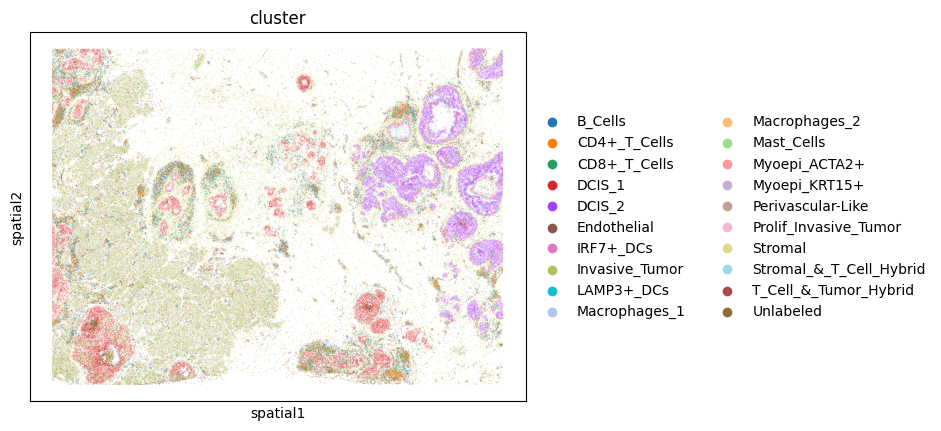

In [21]:
sc.pl.embedding(adata, basis="spatial", color='cluster')

In [22]:
lr_pairs = sp.tl.lr_pairs(
    'human',
    Annotation_key='annotation',
    ligand_key='ligand_symbol',
    receptor_key='receptor_symbol'
)
lr_pairs.get_complexes()

In [23]:
from scipy import sparse
adata = sp.tl.cell_type_level_communication(
    adata=adata,
    lr_pairs=lr_pairs,
    cluster_key='cluster',
    n_iters=100,
    m=0.5,
    contact_key='Cell-Cell Contact',
    secretory_key='Secreted Signaling',
    secretory_radius=100
)

In contact mode, The average number of neighbors is 5.699602597888161
In contact mode, total of 0 spots have no neighbors


9 contact ligand-receptor pairs.:   0%|           [ time left: ? ]

9 contact ligand-receptor pairs.:  11%|█          [ time left: 00:12 ]

9 contact ligand-receptor pairs.:  22%|██▏        [ time left: 00:10 ]

9 contact ligand-receptor pairs.:  33%|███▎       [ time left: 00:09 ]

...

3 secretory ligand-receptor pairs.:   0%|           [ time left: ? ]

3 secretory ligand-receptor pairs.:  33%|███▎       [ time left: 00:24 ]

3 secretory ligand-receptor pairs.:  67%|██████▋    [ time left: 00:12 ]

3 secretory ligand-receptor pairs.: 100%|██████████ [ time left: 00:00 ]

3 secretory ligand-receptor pairs.: 100%|██████████ [ time left: 00:00 ]

In [24]:
get_network_strength(adata,'contact').to_csv("./SOApy/BC_contact.csv")

In [25]:
get_network_strength(adata,"secretory").to_csv("./SOApy/BC_secretory.csv")